In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from heston.pinn.heston_pinn_nd import HestonMultiAssetPINN
from utility.model import ModelConfig, EarlyStopping
from heston.tree import HestonTreeFast

In [2]:
n_assets = 2
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma_bar = 0.3  # Volatility of variance

sigmas = np.array([0.2, 0.25])  # Volatility of each asset

# Correlation matrix
rho_asset = 0 # Correlation between assets
corr = np.full((n_assets, n_assets), rho_asset)
np.fill_diagonal(corr, 1.0)

rho_cross = [0.3, 0.4]  # Correlation between stock price and variance for each asset

S_min = np.full(n_assets, 0.0)
V_min = 0.01

S0 = 1.0
v0 = 0.04

S_max = np.full(n_assets, 3 * S0)
V_max = 5 * v0


In [3]:
input_size = 4
hidden_sizes = [64, 64, 64, 64]
output_size = 1
activation = nn.Sigmoid()
learning_rate = 0.001

# Scheduler
step_size = 2000
gamma = 0.7

model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate,
    step_size=step_size,
    gamma=gamma
)

loss_weights = {
    'variational': 5,
    'terminal': 5,
    'Smin': 3,
    'Smax': 3,
    'Vmin': 3,
    'Vmax': 3
}

In [4]:
seed = 43
pinn = HestonMultiAssetPINN(model_config, seed)
pinn.set_params(K, r, T, kappa, theta, sigma_bar, sigmas, corr, rho_cross, S_min, S_max, V_min, V_max)
pinn.set_loss_weights(loss_weights)

# early_stopping = EarlyStopping(patience=500, min_delta=1e-7)
# pinn.train(batch_size=4096, epochs=30000, early_stopping=early_stopping)
pinn.load(f'../../models/heston_pinn_nd/{seed}.pth')

In [5]:
S1 = np.linspace(S_min[0], S_max[0], 100)
S2 = np.linspace(S_min[1], S_max[1], 100)

V = v0

# Create a grid of stock prices
S1_grid, S2_grid = np.meshgrid(S1, S2)
S_grid = np.stack([S1_grid, S2_grid], axis=-1).reshape(-1, 2)
t = np.zeros((S_grid.shape[0], 1))  # Time to maturity is 0 at maturity
with torch.no_grad():
    model = pinn.model
    model.eval()
    S_tensor = torch.tensor(S_grid, dtype=torch.float32)
    t_tensor = torch.tensor(t, dtype=torch.float32)
    V_tensor = torch.tensor([[V]], dtype=torch.float32).repeat(S_tensor.shape[0], 1)
    nn_prices = model(t_tensor, S_tensor, V_tensor).numpy().reshape(100, 100)

## 1D case

In [6]:
A = np.sum(np.square(sigmas))
b = corr.T @ corr
B = np.sum(np.square(b))

r_1d = n_assets * r + 0.5 * v0 * (B - A)
kappa_1d = kappa
theta_1d = B * theta
sigma_bar_1d = np.sqrt(B) * sigma_bar


In [7]:
n = 100
mv = 3 * n
mz = 6 * n
V0_min = v0 * 0.25
V0_max = v0 * 3
S0_min = S0 * 0.01
S0_max = S0 * 3

rho = np.mean(rho_cross)

heston_tree = HestonTreeFast(n, mz, mv, K, T, r_1d, kappa_1d, theta_1d, sigma_bar_1d, rho)
heston_tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min**2, S0_max=S0_max**2,
                       option_type="put", exercise_type="american")

In [8]:
V = v0
S1 = np.linspace(S0_min, S0_max, 100)
S2 = np.linspace(S0_min, S0_max, 100)

# Create a grid of stock prices
S1_grid, S2_grid = np.meshgrid(S1, S2)
S_grid = np.stack([S1_grid, S2_grid], axis=-1).reshape(-1, 2)

S_prod = S_grid[:, 0] * S_grid[:, 1]
t = np.zeros((S_prod.shape[0], 1))  # Time to maturity is 0 at maturity
prices_ht = heston_tree.price(V, S_prod, 0).reshape(100, 100)

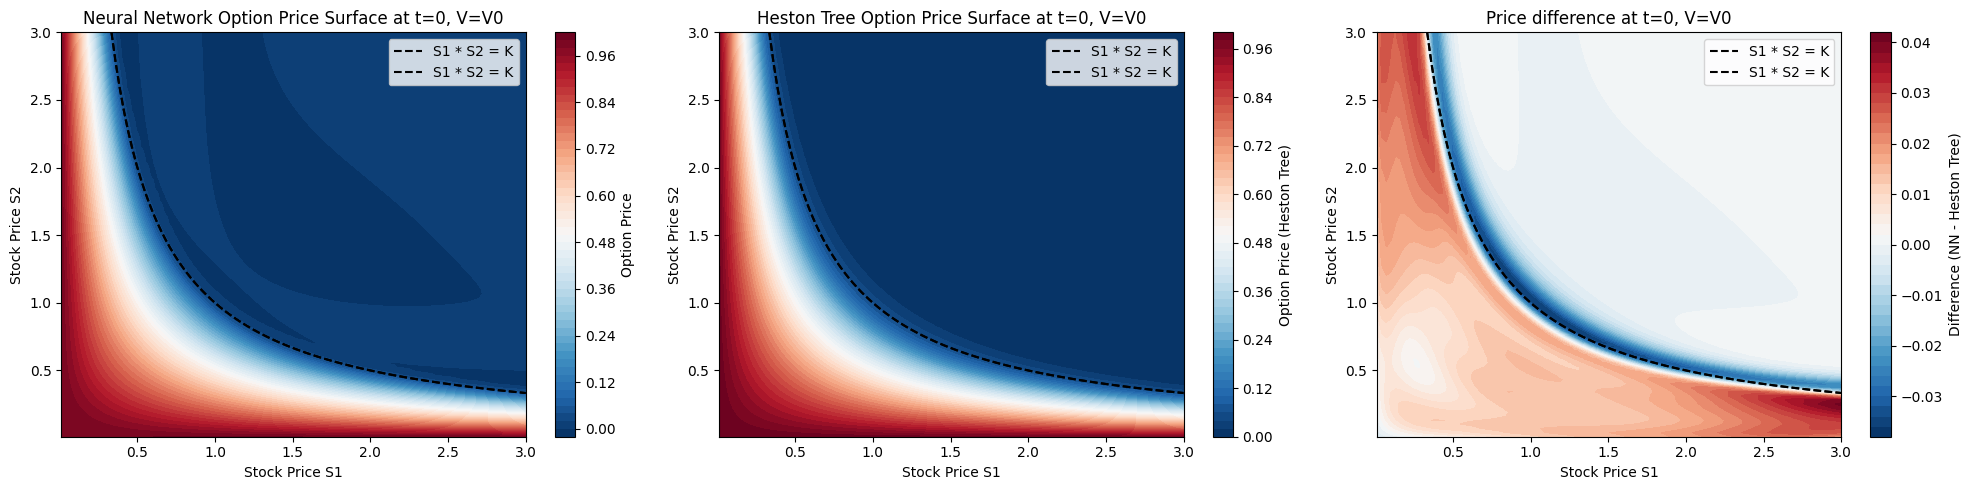

In [9]:
# Plotting the results
Xs = np.linspace(K / S_max, S_max, 100)
Ys = K / Xs

plt.figure(figsize=(20, 5))

# Plot the neural network price surface
plt.subplot(1, 3, 1)
plt.contourf(S1_grid, S2_grid, nn_prices, levels=50, cmap='RdBu_r')
plt.colorbar(label='Option Price')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Neural Network Option Price Surface at t=0, V=V0')
plt.legend()

plt.subplot(1, 3, 2)
plt.contourf(S1_grid, S2_grid, prices_ht, levels=50, cmap='RdBu_r')
plt.colorbar(label='Option Price (Heston Tree)')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Heston Tree Option Price Surface at t=0, V=V0')
plt.legend()

plt.subplot(1, 3, 3)
diff = nn_prices - prices_ht

plt.contourf(S1_grid, S2_grid, diff, levels=50, cmap='RdBu_r')
plt.colorbar(label='Difference (NN - Heston Tree)')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Price difference at t=0, V=V0')
plt.legend()

plt.tight_layout()
plt.show()